# Demand Pattern Evaluation

This notebook checks how each model performs on Regular, Irregular, and 
Intermittent demand separately, using the blind 15-day forecast results 
from the forecasting notebook. The goal is to answer the project's main 
question: does one model work best everywhere, or does the best choice 
depend on the demand pattern?


## 1. Setup and Data Loading

This section loads the required libraries and the model evaluation outputs generated during the forecasting stage.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Loading the Prediction Data

We load the row-level predictions from the forecasting stage. The results from the five forecasting models are stored in the master prediction file, while DeepAR predictions are stored separately and merged here for the final comparison.

In [2]:
# Load predictions from the forecasting models
predictions_df = pd.read_parquet(
    "../data/processed/final_prediction_results.parquet"
)

# Load DeepAR predictions
deepar_df = pd.read_parquet(
    "../predictions/deepar_predictions.parquet"
)

# Keep only the columns needed for the final comparison
deepar_df = deepar_df[
    ["date", "store_nbr", "family", "deepar_pred"]
].copy()

# Merge DeepAR predictions with the master prediction results
predictions_df = predictions_df.merge(
    deepar_df,
    on=["date", "store_nbr", "family"],
    how="left"
)

print("Final prediction shape:", predictions_df.shape)
print("\nDemand pattern counts:")
print(predictions_df["pattern"].value_counts())

print("\nMissing DeepAR predictions:",
      predictions_df["deepar_pred"].isna().sum())

predictions_df.head()

Final prediction shape: (25920, 11)

Demand pattern counts:
pattern
Regular         16920
Irregular        5670
Intermittent     3330
Name: count, dtype: int64

Missing DeepAR predictions: 0


,date,store_nbr,family,sales,pattern,seasonal_naive_pred,xgboost_pred,lightgbm_pred,xgboost_tuned_pred,lightgbm_tuned_pred,deepar_pred
0,2017-08-01,1,AUTOMOTIVE,5.0,Regular,10.0,4.452932,5.747949,5.489812,6.269504,5.041914
1,2017-08-02,1,AUTOMOTIVE,4.0,Regular,2.0,3.371012,3.440070,4.341344,4.746142,5.110836
2,2017-08-03,1,AUTOMOTIVE,3.0,Regular,5.0,2.717625,3.051329,4.405673,2.040151,4.859929
3,2017-08-04,1,AUTOMOTIVE,8.0,Regular,7.0,2.834532,5.004899,4.474223,3.389619,4.341737
4,2017-08-05,1,AUTOMOTIVE,5.0,Regular,4.0,4.335972,8.958764,5.275332,8.547551,4.544546


## 2. Data Quality Checks

Before calculating any metrics, we check the data for missing values, 
duplicates, and negative values, since any of these would distort the 
per-pattern results.

In [3]:
prediction_columns = [
    "seasonal_naive_pred",
    "xgboost_pred",
    "lightgbm_pred",
    "xgboost_tuned_pred",
    "lightgbm_tuned_pred",
    "deepar_pred"
]

print("Missing values:")
print(predictions_df.isna().sum())

print("\nDuplicate rows:", predictions_df.duplicated().sum())

print("\nNegative actual sales:", (predictions_df["sales"] < 0).sum())
print("\nNegative predictions:")
print((predictions_df[prediction_columns] < 0).sum())

Missing values:
date                   0
store_nbr              0
family                 0
sales                  0
pattern                0
seasonal_naive_pred    0
xgboost_pred           0
lightgbm_pred          0
xgboost_tuned_pred     0
lightgbm_tuned_pred    0
deepar_pred            0
dtype: int64

Duplicate rows: 0

Negative actual sales: 0

Negative predictions:
seasonal_naive_pred    0
xgboost_pred           0
lightgbm_pred          0
xgboost_tuned_pred     0
lightgbm_tuned_pred    0
deepar_pred            0
dtype: int64


### Insight

The final prediction table contains 25,920 observations covering the 15-day validation period.

All six model predictions are complete, with no missing values, duplicate rows, negative actual sales, or negative predictions.

This confirms that the prediction data is valid and ready for demand-pattern evaluation.

## 3. Performance by Demand Pattern

This section calculates RMSLE, MAE, and RMSE for each model separately for Regular, Irregular, and Intermittent demand.

RMSLE is used as the primary comparison metric, while MAE and RMSE provide additional error information.

In [4]:
import sys
sys.path.append("../")
from src.evaluation import evaluate

models = {
    "Seasonal Naive": "seasonal_naive_pred",
    "XGBoost": "xgboost_pred",
    "LightGBM": "lightgbm_pred",
    "XGBoost Tuned": "xgboost_tuned_pred",
    "LightGBM Tuned": "lightgbm_tuned_pred",
    "DeepAR": "deepar_pred"
}

pattern_results = []

for pattern in predictions_df["pattern"].unique():
    subset = predictions_df[predictions_df["pattern"] == pattern]
    
    for model_name, pred_col in models.items():
        result = evaluate(subset["sales"], subset[pred_col], name=model_name)
        result["Pattern"] = pattern
        pattern_results.append(result)

pattern_metrics = pd.DataFrame(pattern_results)[["Pattern", "Model", "RMSLE", "MAE", "RMSE"]]
pattern_metrics

Seasonal Naive       MAE:   145.59 | RMSE:   445.99 | RMSLE: 0.5127 | WMAPE:  20.90%
XGBoost              MAE:   122.80 | RMSE:   349.54 | RMSLE: 0.4776 | WMAPE:  17.63%
LightGBM             MAE:   125.64 | RMSE:   354.08 | RMSLE: 0.4476 | WMAPE:  18.04%
XGBoost Tuned        MAE:   123.27 | RMSE:   361.27 | RMSLE: 0.4155 | WMAPE:  17.70%
LightGBM Tuned       MAE:   124.26 | RMSE:   355.30 | RMSLE: 0.4530 | WMAPE:  17.84%
DeepAR               MAE:   110.71 | RMSE:   347.67 | RMSLE: 0.3796 | WMAPE:  15.89%
Seasonal Naive       MAE:     1.00 | RMSE:     3.89 | RMSLE: 0.6156 | WMAPE:  97.02%
XGBoost              MAE:     1.07 | RMSE:     3.63 | RMSLE: 0.5769 | WMAPE: 103.86%
LightGBM             MAE:     1.75 | RMSE:     3.40 | RMSLE: 0.8400 | WMAPE: 169.96%
XGBoost Tuned        MAE:     1.44 | RMSE:     6.22 | RMSLE: 0.5701 | WMAPE: 140.12%
LightGBM Tuned       MAE:     1.30 | RMSE:     4.95 | RMSLE: 0.6316 | WMAPE: 126.89%
DeepAR               MAE:     0.94 | RMSE:     4.03 | RMSLE: 0.50

,Pattern,Model,RMSLE,MAE,RMSE
0,Regular,Seasonal Naive,0.512734,145.593066,445.990868
1,Regular,XGBoost,0.477644,122.801367,349.539731
2,Regular,LightGBM,0.447566,125.639483,354.080195
3,Regular,XGBoost Tuned,0.415478,123.270875,361.269363
4,Regular,LightGBM Tuned,0.452956,124.263447,355.295001
5,Regular,DeepAR,0.379611,110.711543,347.666442
6,Intermittent,Seasonal Naive,0.615612,0.996997,3.889000
7,Intermittent,XGBoost,0.576921,1.067262,3.633730
8,Intermittent,LightGBM,0.839973,1.746557,3.399336
9,Intermittent,XGBoost Tuned,0.570136,1.439953,6.216061


### Insight

Model performance varies across demand patterns.

DeepAR achieves the lowest RMSLE for Regular demand (0.380) and Intermittent demand (0.506), while XGBoost Tuned performs best on Irregular demand (0.576).

This shows that the best-performing model depends on the underlying demand pattern rather than one model consistently outperforming all others.

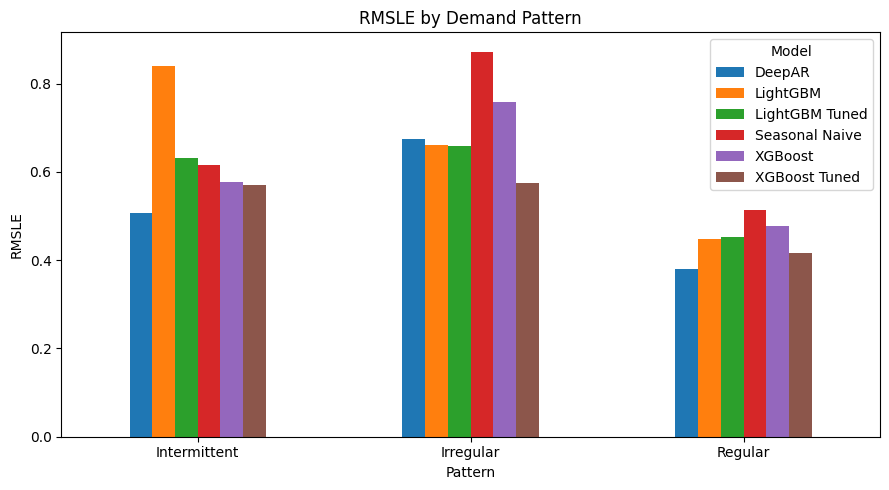

In [5]:
import matplotlib.pyplot as plt

pattern_metrics.pivot(
    index="Pattern",
    columns="Model",
    values="RMSLE"
).plot(kind="bar", figsize=(9, 5))

plt.ylabel("RMSLE")
plt.title("RMSLE by Demand Pattern")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### Insight

Hyperparameter tuning improves XGBoost across all three demand patterns, but the size of the improvement varies.

For XGBoost, RMSLE improves from 0.478 to 0.415 on Regular demand, from 0.759 to 0.576 on Irregular demand, and from 0.577 to 0.570 on Intermittent demand.

The largest improvement occurs on Irregular demand, where tuning reduces RMSLE by approximately 24%.

For LightGBM, tuning improves RMSLE on Irregular demand from 0.660 to 0.659 and on Intermittent demand from 0.840 to 0.632, while Regular demand shows a small increase from 0.448 to 0.453.

This indicates that hyperparameter tuning has a stronger effect on some demand patterns than others.

## 4. Best Model per Pattern

This section pulls out the single best model for each demand pattern, 
based on RMSLE, into one clear table.

In [6]:
best_models = pattern_metrics.loc[
    pattern_metrics.groupby("Pattern")["RMSLE"].idxmin()
]

best_models

,Pattern,Model,RMSLE,MAE,RMSE
11,Intermittent,DeepAR,0.506396,0.943417,4.034140
15,Irregular,XGBoost Tuned,0.575605,26.079496,80.131552
5,Regular,DeepAR,0.379611,110.711543,347.666442


### Insight

The best-performing model changes across demand patterns.

- Regular: DeepAR — RMSLE 0.380
- Irregular: XGBoost Tuned — RMSLE 0.575
- Intermittent: DeepAR — RMSLE 0.506

This confirms that model selection should consider demand characteristics rather than relying on a single model across all series.

## 5. Intermittent Demand by Family

This section checks model performance within the Intermittent group at 
the family level, to see if the best model is consistent across 
families or changes from one family to another.

In [7]:
intermittent_df = predictions_df[
    predictions_df["pattern"] == "Intermittent"
].copy()

family_results = []

for family in intermittent_df["family"].unique():
    subset = intermittent_df[
        intermittent_df["family"] == family
    ]

    for model_name, pred_col in models.items():
        result = evaluate(
            subset["sales"],
            subset[pred_col],
            name=model_name
        )

        result["Family"] = family
        family_results.append(result)

family_metrics = pd.DataFrame(family_results)

family_metrics = family_metrics[
    ["Family", "Model", "RMSLE", "MAE", "RMSE"]
]

family_metrics.sort_values(
    ["Family", "RMSLE"]
).reset_index(drop=True)

Seasonal Naive       MAE:     0.05 | RMSE:     0.25 | RMSLE: 0.1634 | WMAPE: 212.50%
XGBoost              MAE:     0.26 | RMSE:     0.65 | RMSLE: 0.3806 | WMAPE: 1021.35%
LightGBM             MAE:     1.41 | RMSE:     1.96 | RMSLE: 0.8778 | WMAPE: 5533.60%
XGBoost Tuned        MAE:     0.67 | RMSE:     0.70 | RMSLE: 0.5182 | WMAPE: 2656.43%
LightGBM Tuned       MAE:     0.48 | RMSE:     1.11 | RMSLE: 0.5247 | WMAPE: 1896.21%
DeepAR               MAE:     0.12 | RMSE:     0.22 | RMSLE: 0.1617 | WMAPE: 462.24%
Seasonal Naive       MAE:     0.30 | RMSE:     0.69 | RMSLE: 0.3932 | WMAPE: 229.55%
XGBoost              MAE:     0.32 | RMSE:     0.72 | RMSLE: 0.4174 | WMAPE: 246.68%
LightGBM             MAE:     1.45 | RMSE:     2.01 | RMSLE: 0.8843 | WMAPE: 1113.68%
XGBoost Tuned        MAE:     0.67 | RMSE:     0.72 | RMSLE: 0.5085 | WMAPE: 513.60%
LightGBM Tuned       MAE:     0.56 | RMSE:     1.17 | RMSLE: 0.5499 | WMAPE: 431.56%
DeepAR               MAE:     0.31 | RMSE:     0.45 | RMSLE:

,Family,Model,RMSLE,MAE,RMSE
0,BABY CARE,DeepAR,0.307150,0.294766,0.563593
1,BABY CARE,Seasonal Naive,0.419037,0.341667,0.767029
2,BABY CARE,XGBoost,0.468148,0.405478,0.828209
3,BABY CARE,XGBoost Tuned,0.512670,0.696941,0.777681
4,BABY CARE,LightGBM Tuned,0.582787,0.628782,1.238374
5,BABY CARE,LightGBM,0.875468,1.445049,2.013453
6,BEAUTY,DeepAR,0.571870,0.987152,1.277880
7,BEAUTY,LightGBM Tuned,0.607683,1.005266,1.585933
8,BEAUTY,XGBoost,0.636550,1.016626,1.543984
9,BEAUTY,XGBoost Tuned,0.736474,1.558547,2.064740


In [8]:
best_family_models = family_metrics.loc[
    family_metrics.groupby("Family")["RMSLE"].idxmin()
]

print(best_family_models.sort_values("RMSLE"))
print("\nWin count:")
print(best_family_models["Model"].value_counts())

                        Family          Model     RMSLE       MAE       RMSE
5                        BOOKS         DeepAR  0.161725  0.117393   0.217058
11             HOME APPLIANCES         DeepAR  0.288748  0.310296   0.445491
23                   BABY CARE         DeepAR  0.307150  0.294766   0.563593
29                    HARDWARE         DeepAR  0.448642  0.687514   0.922716
41                   MAGAZINES         DeepAR  0.483619  0.849877   1.200614
35             LAWN AND GARDEN         DeepAR  0.485021  1.293199   2.915484
47                PET SUPPLIES         DeepAR  0.522691  0.957093   1.357503
65     PLAYERS AND ELECTRONICS         DeepAR  0.543833  0.954938   1.400335
51                  LADIESWEAR  XGBoost Tuned  0.555764  1.279822   1.889425
59                      BEAUTY         DeepAR  0.571870  0.987152   1.277880
15  SCHOOL AND OFFICE SUPPLIES  XGBoost Tuned  0.676863  4.161743  14.942291
71                     SEAFOOD         DeepAR  0.708063  1.283011   1.767573

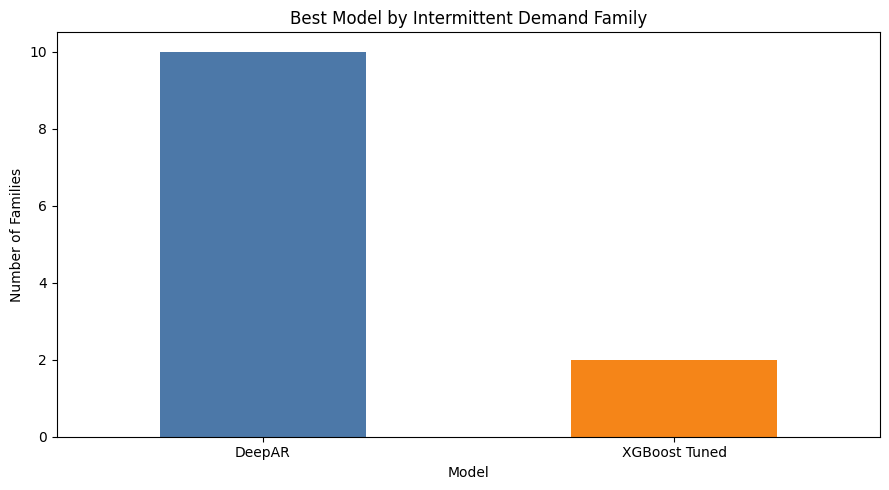

In [9]:
win_counts = best_family_models["Model"].value_counts()

ax = win_counts.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2"]
)

plt.ylabel("Number of Families")
plt.xlabel("Model")
plt.title("Best Model by Intermittent Demand Family")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

The family-level analysis shows that model performance varies within the Intermittent demand group.

DeepAR achieves the lowest RMSLE in 10 of the 12 intermittent product families, while XGBoost Tuned performs best in the remaining 2 families.

This shows that even within the same demand pattern, model performance can vary by product family.

## 6. Prediction and Error Analysis

This section examines how the forecasting models behave at the prediction level.

The analysis focuses on the size and distribution of forecast errors,
including the largest errors and the relationship between forecast errors
and actual demand.

In [10]:
model_columns = {
    "Seasonal Naive": "seasonal_naive_pred",
    "XGBoost": "xgboost_pred",
    "LightGBM": "lightgbm_pred",
    "XGBoost Tuned": "xgboost_tuned_pred",
    "LightGBM Tuned": "lightgbm_tuned_pred",
    "DeepAR": "deepar_pred"
}

error_df = predictions_df[
    ["date", "store_nbr", "family", "sales", "pattern"]
].copy()

for model, column in model_columns.items():
    error_df[f"{model}_abs_error"] = (
        predictions_df["sales"] - predictions_df[column]
    ).abs()

error_df.head()

,date,store_nbr,family,sales,pattern,Seasonal Naive_abs_error,XGBoost_abs_error,LightGBM_abs_error,XGBoost Tuned_abs_error,LightGBM Tuned_abs_error,DeepAR_abs_error
0,2017-08-01,1,AUTOMOTIVE,5.0,Regular,5.0,0.547068,0.747949,0.489812,1.269504,0.041914
1,2017-08-02,1,AUTOMOTIVE,4.0,Regular,2.0,0.628988,0.559930,0.341344,0.746142,1.110836
2,2017-08-03,1,AUTOMOTIVE,3.0,Regular,2.0,0.282375,0.051329,1.405673,0.959849,1.859929
3,2017-08-04,1,AUTOMOTIVE,8.0,Regular,1.0,5.165468,2.995101,3.525777,4.610381,3.658263
4,2017-08-05,1,AUTOMOTIVE,5.0,Regular,1.0,0.664028,3.958764,0.275332,3.547551,0.455454


### Largest Forecast Errors

The largest absolute errors are examined to identify observations where
the forecasts deviate most from actual demand.

In [11]:
largest_errors = []

for model, column in model_columns.items():
    temp = error_df[
        [
            "date",
            "store_nbr",
            "family",
            "pattern",
            "sales",
            f"{model}_abs_error"
        ]
    ].copy()

    temp["Model"] = model
    temp = temp.rename(
        columns={
            f"{model}_abs_error": "Absolute_Error"
        }
    )

    largest_errors.append(temp)

largest_errors = pd.concat(
    largest_errors,
    ignore_index=True
)

largest_errors = largest_errors.sort_values(
    "Absolute_Error",
    ascending=False
).head(20)

largest_errors

,date,store_nbr,family,pattern,sales,Absolute_Error,Model
130035,2017-08-01,1,PRODUCE,Regular,2560.610,14376.132187,DeepAR
136170,2017-08-01,14,HOME CARE,Irregular,266.000,9948.629883,DeepAR
98608,2017-08-14,44,GROCERY I,Regular,8318.000,8473.523438,XGBoost Tuned
20712,2017-08-13,44,BEVERAGES,Regular,10491.000,7849.000000,Seasonal Naive
99088,2017-08-14,45,GROCERY I,Regular,9665.000,7126.523438,XGBoost Tuned
20711,2017-08-12,44,BEVERAGES,Regular,9624.000,6463.000000,Seasonal Naive
155120,2017-08-06,54,BEVERAGES,Regular,8552.000,6235.955078,DeepAR
125488,2017-08-14,46,GROCERY I,Regular,7570.000,5897.307882,LightGBM Tuned
22152,2017-08-13,47,BEVERAGES,Regular,10279.000,5595.000000,Seasonal Naive
21807,2017-08-13,46,GROCERY I,Regular,10557.000,5520.000000,Seasonal Naive


### Actual vs Forecast

Actual demand is compared with the selected best-performing model for
each demand pattern over the validation period.

In [12]:
best_model_predictions = {}

for _, row in best_models.iterrows():
    pattern = row["Pattern"]
    model = row["Model"]
    pred_col = model_columns[model]

    subset = predictions_df[
        predictions_df["pattern"] == pattern
    ].copy()

    series = (
        subset
        .groupby("date")
        .agg(
            Actual=("sales", "sum"),
            Forecast=(pred_col, "sum")
        )
        .reset_index()
    )

    best_model_predictions[pattern] = {
        "Model": model,
        "Data": series
    }

best_model_predictions

{'Intermittent': {'Model': 'DeepAR',
  'Data':          date  Actual    Forecast
  0  2017-08-01   202.0  136.365524
  1  2017-08-02   161.0  119.196991
  2  2017-08-03   145.0  116.599571
  3  2017-08-04   155.0  119.330551
  4  2017-08-05   279.0  146.758957
  5  2017-08-06   243.0  153.564209
  6  2017-08-07   179.0  114.427521
  7  2017-08-08   159.0  106.465202
  8  2017-08-09   183.0  109.749260
  9  2017-08-10   201.0  103.537971
  10 2017-08-11   286.0  107.326912
  11 2017-08-12   347.0  139.389114
  12 2017-08-13   294.0  150.566574
  13 2017-08-14   302.0  115.262459
  14 2017-08-15   286.0  109.598022},
 'Irregular': {'Model': 'XGBoost Tuned',
  'Data':          date       Actual      Forecast
  0  2017-08-01  66120.64810  53057.890625
  1  2017-08-02  42110.51100  37052.003906
  2  2017-08-03  35244.48502  33763.648438
  3  2017-08-04  36314.04000  36398.023438
  4  2017-08-05  45995.52300  47503.140625
  5  2017-08-06  51455.32200  51350.000000
  6  2017-08-07  38910.5340

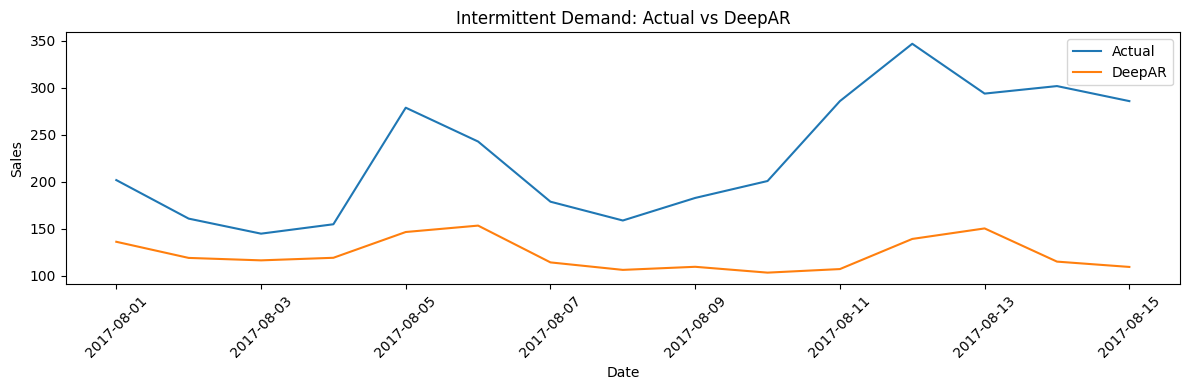

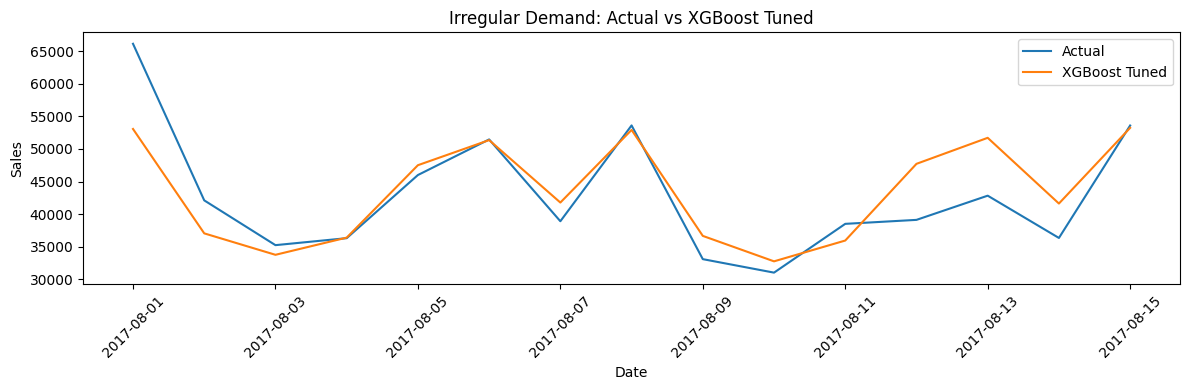

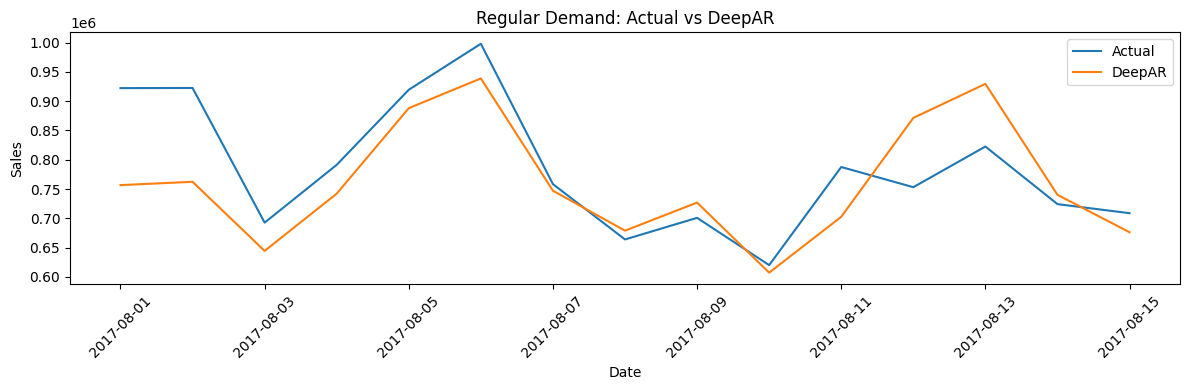

In [13]:
for pattern, result in best_model_predictions.items():
    data = result["Data"]
    model = result["Model"]

    plt.figure(figsize=(12, 4))

    plt.plot(
        data["date"],
        data["Actual"],
        label="Actual"
    )

    plt.plot(
        data["date"],
        data["Forecast"],
        label=model
    )

    plt.title(f"{pattern} Demand: Actual vs {model}")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Error Context Analysis

Forecast errors are examined in relation to promotion, holidays, weekends,
and unusually high demand to identify conditions associated with larger
forecast deviations.

In [14]:
# Load holiday information for error-context analysis
holidays = pd.read_csv(
    "../data/raw/holidays_events.csv"
)

holidays["date"] = pd.to_datetime(holidays["date"])

national_holidays = set(
    holidays[
        (holidays["locale"] == "National") &
        (holidays["transferred"] == False)
    ]["date"]
)

error_df["is_holiday"] = error_df["date"].isin(
    national_holidays
)

error_df["is_weekend"] = (
    error_df["date"].dt.dayofweek >= 5
)
# Load validation data for contextual features
valid_df = pd.read_parquet(
    "../data/processed/valid_df.parquet"
)

valid_df["date"] = pd.to_datetime(
    valid_df["date"]
)

valid_df[
    [
        "date",
        "store_nbr",
        "family",
        "onpromotion"
    ]
].head()

,date,store_nbr,family,onpromotion
0,2017-08-01,1,AUTOMOTIVE,0
1,2017-08-02,1,AUTOMOTIVE,0
2,2017-08-03,1,AUTOMOTIVE,0
3,2017-08-04,1,AUTOMOTIVE,0
4,2017-08-05,1,AUTOMOTIVE,0


In [15]:
promotion_context = valid_df[
    [
        "date",
        "store_nbr",
        "family",
        "onpromotion"
    ]
].copy()

error_df = error_df.merge(
    promotion_context,
    on=["date", "store_nbr", "family"],
    how="left"
)

error_df["onpromotion"] = (
    error_df["onpromotion"].fillna(0)
)

In [16]:
error_df[
    [
        "date",
        "store_nbr",
        "family",
        "sales",
        "onpromotion",
        "is_holiday",
        "is_weekend"
    ]
].head()

,date,store_nbr,family,sales,onpromotion,is_holiday,is_weekend
0,2017-08-01,1,AUTOMOTIVE,5.0,0,False,False
1,2017-08-02,1,AUTOMOTIVE,4.0,0,False,False
2,2017-08-03,1,AUTOMOTIVE,3.0,0,False,False
3,2017-08-04,1,AUTOMOTIVE,8.0,0,False,False
4,2017-08-05,1,AUTOMOTIVE,5.0,0,False,True


In [17]:
# Identify unusually high-demand observations
spike_threshold = error_df["sales"].quantile(0.90)

error_df["is_sales_spike"] = (
    error_df["sales"] >= spike_threshold
)

spike_threshold

np.float64(1246.2360000000042)

In [18]:
context_results = []

contexts = {
    "Promotion": "onpromotion",
    "Holiday": "is_holiday",
    "Weekend": "is_weekend",
    "Sales Spike": "is_sales_spike"
}

for context_name, context_col in contexts.items():

    for context_value in [True, False]:

        subset = error_df[
            error_df[context_col].astype(bool) == context_value
        ]

        for model, pred_col in model_columns.items():

            metrics = evaluate(
                subset["sales"],
                predictions_df.loc[subset.index, pred_col],
                name=model
            )

            context_results.append({
                "Context": context_name,
                "Condition": (
                    context_name
                    if context_value
                    else f"Non-{context_name}"
                ),
                "Model": model,
                "RMSLE": metrics["RMSLE"],
                "MAE": metrics["MAE"],
                "Rows": len(subset)
            })

context_metrics = pd.DataFrame(context_results)

context_metrics

Seasonal Naive       MAE:   208.73 | RMSE:   535.46 | RMSLE: 0.6164 | WMAPE:  21.17%
XGBoost              MAE:   175.15 | RMSE:   419.52 | RMSLE: 0.3765 | WMAPE:  17.76%
LightGBM             MAE:   179.42 | RMSE:   425.25 | RMSLE: 0.4101 | WMAPE:  18.19%
XGBoost Tuned        MAE:   176.14 | RMSE:   433.59 | RMSLE: 0.3766 | WMAPE:  17.86%
LightGBM Tuned       MAE:   177.04 | RMSE:   426.20 | RMSLE: 0.3908 | WMAPE:  17.95%
DeepAR               MAE:   161.62 | RMSE:   430.58 | RMSLE: 0.4737 | WMAPE:  16.39%
Seasonal Naive       MAE:    12.62 | RMSE:    48.13 | RMSLE: 0.6265 | WMAPE:  21.98%
XGBoost              MAE:    12.04 | RMSE:    47.21 | RMSLE: 0.6815 | WMAPE:  20.96%
LightGBM             MAE:    12.56 | RMSE:    46.98 | RMSLE: 0.6638 | WMAPE:  21.86%
XGBoost Tuned        MAE:    11.52 | RMSE:    45.68 | RMSLE: 0.5457 | WMAPE:  20.05%
LightGBM Tuned       MAE:    12.20 | RMSE:    47.57 | RMSLE: 0.6215 | WMAPE:  21.24%
DeepAR               MAE:    10.18 | RMSE:    41.50 | RMSLE: 0.47

,Context,Condition,Model,RMSLE,MAE,Rows
0,Promotion,Promotion,Seasonal Naive,0.616389,208.729907,11784
1,Promotion,Promotion,XGBoost,0.376507,175.152545,11784
2,Promotion,Promotion,LightGBM,0.410142,179.423466,11784
3,Promotion,Promotion,XGBoost Tuned,0.376626,176.139074,11784
4,Promotion,Promotion,LightGBM Tuned,0.390804,177.044863,11784
5,Promotion,Promotion,DeepAR,0.473699,161.622682,11784
6,Promotion,Non-Promotion,Seasonal Naive,0.626537,12.623361,14136
7,Promotion,Non-Promotion,XGBoost,0.681509,12.036840,14136
8,Promotion,Non-Promotion,LightGBM,0.663815,12.555092,14136
9,Promotion,Non-Promotion,XGBoost Tuned,0.545747,11.515715,14136


In [19]:
context_winners = (
    context_metrics
    .loc[
        context_metrics
        .groupby(["Context", "Condition"])["RMSLE"]
        .idxmin()
    ]
    .sort_values(["Context", "Condition"])
    .reset_index(drop=True)
)

context_winners

,Context,Condition,Model,RMSLE,MAE,Rows
0,Holiday,Holiday,XGBoost Tuned,0.512583,90.647003,1728
1,Holiday,Non-Holiday,DeepAR,0.472674,77.737368,24192
2,Promotion,Non-Promotion,DeepAR,0.478173,10.181020,14136
3,Promotion,Promotion,XGBoost,0.376507,175.152545,11784
4,Sales Spike,Non-Sales Spike,DeepAR,0.494740,27.521217,23328
5,Sales Spike,Sales Spike,XGBoost Tuned,0.233287,574.126317,2592
6,Weekend,Non-Weekend,XGBoost Tuned,0.468477,76.784712,19008
7,Weekend,Weekend,DeepAR,0.466126,88.623089,6912


### Error Context Findings

Model performance varies across different demand conditions. XGBoost Tuned performs best during holidays, sales spikes, and non-weekend observations, while XGBoost performs best during promotions. DeepAR performs best under non-promotion, non-holiday, non-sales-spike, and weekend conditions.

This suggests that the relative performance of the models changes with the demand context rather than one model consistently dominating every condition.

## 7. Overall Model Comparison

This section compares all forecasting models across the complete
15-day validation set using the same evaluation metrics.

In [20]:
overall_results = []

for model, pred_col in model_columns.items():
    metrics = evaluate(
        predictions_df["sales"],
        predictions_df[pred_col],
        name=model
    )

    overall_results.append(metrics)

overall_metrics = pd.DataFrame(overall_results)[
    ["Model", "RMSLE", "MAE", "RMSE", "WMAPE"]
].sort_values("RMSLE")

overall_metrics

Seasonal Naive       MAE:   101.78 | RMSE:   362.79 | RMSLE: 0.6219 | WMAPE:  21.22%
XGBoost              MAE:    86.19 | RMSE:   285.01 | RMSLE: 0.5637 | WMAPE:  17.97%
LightGBM             MAE:    88.42 | RMSE:   288.82 | RMSLE: 0.5628 | WMAPE:  18.43%
XGBoost Tuned        MAE:    86.36 | RMSE:   294.29 | RMSLE: 0.4764 | WMAPE:  18.00%
LightGBM Tuned       MAE:    87.14 | RMSE:   289.51 | RMSLE: 0.5293 | WMAPE:  18.17%
DeepAR               MAE:    79.03 | RMSE:   291.94 | RMSLE: 0.4761 | WMAPE:  16.48%


,Model,RMSLE,MAE,RMSE,WMAPE
5,DeepAR,0.476144,79.030887,291.935624,16.475729
3,XGBoost Tuned,0.476362,86.358372,294.291055,18.003305
4,LightGBM Tuned,0.529260,87.144461,289.512767,18.167182
2,LightGBM,0.562844,88.418399,288.824248,18.432763
1,XGBoost,0.563690,86.194072,285.008961,17.969053
0,Seasonal Naive,0.621944,101.779207,362.785312,21.218117


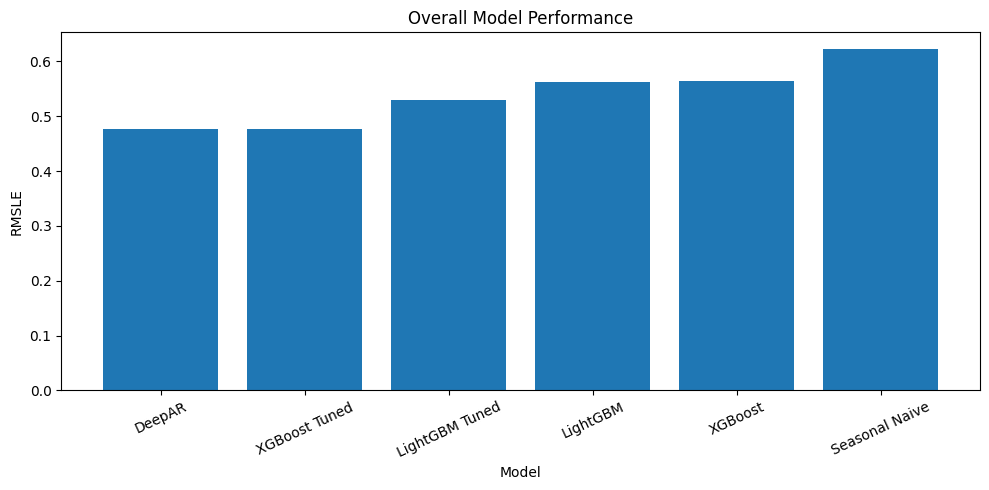

In [21]:
plt.figure(figsize=(10, 5))

plt.bar(
    overall_metrics["Model"],
    overall_metrics["RMSLE"]
)

plt.xlabel("Model")
plt.ylabel("RMSLE")
plt.title("Overall Model Performance")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### Baseline vs Tuned Models

This comparison shows the effect of hyperparameter tuning on XGBoost and LightGBM using the overall validation RMSLE.

In [22]:
tuning_comparison = overall_metrics[
    overall_metrics["Model"].isin([
        "XGBoost",
        "XGBoost Tuned",
        "LightGBM",
        "LightGBM Tuned"
    ])
].copy()

tuning_comparison.sort_values("RMSLE")

,Model,RMSLE,MAE,RMSE,WMAPE
3,XGBoost Tuned,0.476362,86.358372,294.291055,18.003305
4,LightGBM Tuned,0.529260,87.144461,289.512767,18.167182
2,LightGBM,0.562844,88.418399,288.824248,18.432763
1,XGBoost,0.563690,86.194072,285.008961,17.969053


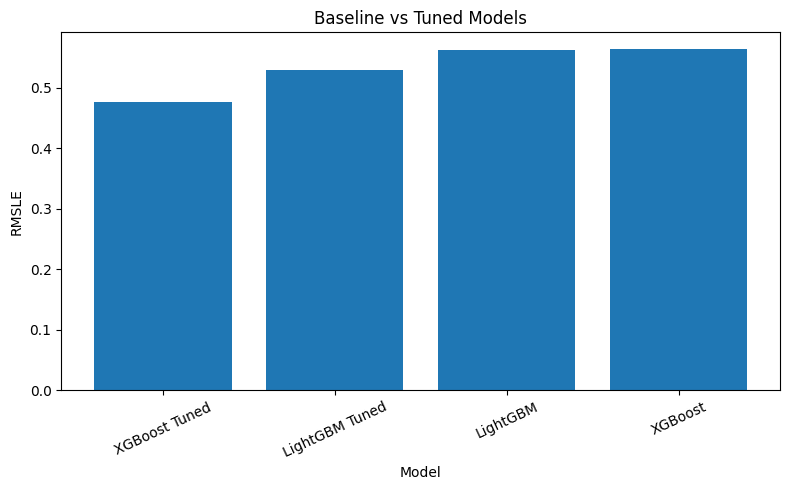

In [23]:
plt.figure(figsize=(8, 5))

plt.bar(
    tuning_comparison["Model"],
    tuning_comparison["RMSLE"]
)

plt.xlabel("Model")
plt.ylabel("RMSLE")
plt.title("Baseline vs Tuned Models")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### Tuning Findings

Hyperparameter tuning improved the overall RMSLE of both tree-based models. XGBoost improved from 0.5637 to 0.4764, while LightGBM improved from 0.5628 to 0.5293. The improvement was larger for XGBoost, indicating that tuning had a stronger effect on its validation performance.

## 8. Final Model Selection

The final model is selected based on overall validation performance,
performance across demand patterns, and performance across intermittent
product families. Error-context analysis is used to further understand
model behavior under different demand conditions.

In [24]:
# Build final model comparison from overall, pattern, and family-level results

pattern_win_counts = (
    best_models
    .groupby("Model")
    .size()
    .reset_index(name="Pattern_Wins")
)

family_win_counts = (
    best_family_models
    .groupby("Model")
    .size()
    .reset_index(name="Family_Wins")
)

final_comparison = overall_metrics[
    ["Model", "RMSLE", "MAE", "RMSE", "WMAPE"]
].copy()

final_comparison = final_comparison.merge(
    pattern_win_counts,
    on="Model",
    how="left"
)

final_comparison = final_comparison.merge(
    family_win_counts,
    on="Model",
    how="left"
)

final_comparison["Pattern_Wins"] = (
    final_comparison["Pattern_Wins"]
    .fillna(0)
    .astype(int)
)

final_comparison["Family_Wins"] = (
    final_comparison["Family_Wins"]
    .fillna(0)
    .astype(int)
)

final_comparison = final_comparison.sort_values(
    "RMSLE"
).reset_index(drop=True)

final_comparison

,Model,RMSLE,MAE,RMSE,WMAPE,Pattern_Wins,Family_Wins
0,DeepAR,0.476144,79.030887,291.935624,16.475729,2,10
1,XGBoost Tuned,0.476362,86.358372,294.291055,18.003305,1,2
2,LightGBM Tuned,0.529260,87.144461,289.512767,18.167182,0,0
3,LightGBM,0.562844,88.418399,288.824248,18.432763,0,0
4,XGBoost,0.563690,86.194072,285.008961,17.969053,0,0
5,Seasonal Naive,0.621944,101.779207,362.785312,21.218117,0,0


### Final Selection

DeepAR is selected as the final forecasting model based on the lowest overall RMSLE (0.4761). It also achieves the best performance in the Regular and Intermittent demand patterns and has the strongest coverage across intermittent product families, achieving the lowest RMSLE in 10 of 12 families.

XGBoost Tuned remains a strong complementary model, achieving the best performance for Irregular demand and in 2 of the 12 intermittent families. Its overall RMSLE (0.4764) is also very close to DeepAR.

## 9. Conclusion

The validation results show that DeepAR achieved the lowest overall RMSLE (0.4761) across the 15-day validation period. It also performed best for Regular and Intermittent demand, while XGBoost Tuned performed best for Irregular demand.

For intermittent demand, DeepAR achieved the lowest RMSLE in 10 of 12 product families, with XGBoost Tuned leading in the remaining 2 families.

Hyperparameter tuning improved both tree-based models, with XGBoost showing a larger overall improvement than LightGBM.

Error-context analysis showed that model performance varies across demand conditions. XGBoost Tuned performed best during holidays, sales spikes, and non-weekend observations, while XGBoost performed best during promotions. DeepAR performed best under non-promotion, non-holiday, non-sales-spike, and weekend conditions.

Based on the overall validation performance and broader coverage across demand patterns and intermittent product families, DeepAR was selected as the final forecasting model, with XGBoost Tuned retained as a strong complementary model.

## 10. Final Validation

Before saving the results, we run a final check to confirm that the prediction table and evaluation results are complete and valid.

In [25]:
# Final validation checks

prediction_columns = [
    "seasonal_naive_pred",
    "xgboost_pred",
    "lightgbm_pred",
    "xgboost_tuned_pred",
    "lightgbm_tuned_pred",
    "deepar_pred"
]

validation_summary = {
    "Prediction Rows": len(predictions_df),
    "Expected Rows": 25920,
    "Missing Predictions": predictions_df[prediction_columns].isna().sum().sum(),
    "Duplicate Rows": predictions_df.duplicated(
        ["date", "store_nbr", "family"]
    ).sum(),
    "Negative Actuals": (predictions_df["sales"] < 0).sum(),
    "Negative Predictions": (
        predictions_df[prediction_columns] < 0
    ).sum().sum(),
    "Unique Series": predictions_df[
        ["store_nbr", "family"]
    ].drop_duplicates().shape[0],
    "Unique Dates": predictions_df["date"].nunique()
}

pd.Series(validation_summary)

Prediction Rows         25920
Expected Rows           25920
Missing Predictions         0
Duplicate Rows              0
Negative Actuals            0
Negative Predictions        0
Unique Series            1728
Unique Dates               15
dtype: int64

### Validation Result

All final prediction checks passed. The evaluation set contains 25,920
prediction rows covering 1,728 Store × Family series across the 15-day
validation period, with no missing predictions, duplicate rows, or negative
values.

## 11. Save Evaluation Results

The final evaluation results are saved so they can be reused by the
project's reporting and downstream analysis stages.

In [26]:
# Save evaluation results

output_dir = "../outputs"

pattern_metrics.to_csv(
    f"{output_dir}/pattern_level_metrics.csv",
    index=False
)

family_metrics.to_csv(
    f"{output_dir}/intermittent_family_metrics.csv",
    index=False
)

best_family_models.to_csv(
    f"{output_dir}/intermittent_best_model_by_family.csv",
    index=False
)

overall_metrics.to_csv(
    f"{output_dir}/overall_model_metrics.csv",
    index=False
)

context_metrics.to_csv(
    f"{output_dir}/error_context_metrics.csv",
    index=False
)

context_winners.to_csv(
    f"{output_dir}/error_context_winners.csv",
    index=False
)

final_comparison.to_csv(
    f"{output_dir}/final_model_comparison.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.
